# 0. Packages

In [1]:
# !pip install openml shap imblearn

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, RobustScaler, MaxAbsScaler, Normalizer, StandardScaler
# from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score, accuracy_score, r2_score, roc_auc_score, f1_score, balanced_accuracy_score
import sklearn
import seaborn as sns
import gc

import os
from os.path import dirname, join as pathjoin
import scipy.io as sio

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from glob import glob

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append("../utils/")
from util_selector import *
from util_preprocessing import *
from util_postprocessing import *
from util_models import *

sys.path.append("../")
from experiment_setup import *

np.random.seed(RANDOM_STATE)
sklearn.random.seed(RANDOM_STATE)


## Selected ML models 

In [3]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier 

from sklearn.feature_selection import SelectKBest #, SelectPercentile

In [4]:
# BaggingClassifier?
# RandomForestClassifier?
# GaussianNB

for clf in clf_list:
    print(clf.__name__)

KNeighborsClassifier
LinearSVC
RandomForestClassifier
XGBClassifier
MLPClassifier
GaussianNB


# 1. Dataset

In [5]:

data_dir = pathjoin('.', 'inputs', 'datasets.mat', 'bio_data')
datasets_list = get_datasets_list_from_dir_and_subdirs(data_dir)
datasets_list.sort() 
# datasets_list.reverse() 


datasets_with_negative_labels = []
for filename in datasets_list:
    contents = sio.loadmat(filename)
    X, y = contents['X'], contents['Y']
    y = y.reshape(1,-1)[0]
    # print(f"------- {filename.split("/")[-1]} -------")
    # print(X.shape,X.min().min(), X.max().max())
    labels_index = list(pd.Series(y).value_counts(dropna=False).index)
    # print(labels_index)
    if -1 in labels_index:
        datasets_with_negative_labels+=[filename.split("/")[-1]]


In [6]:
datasets_with_negative_labels#, datasets_list

['colon.mat', 'leukemia.mat']

In [7]:
# sio?
!ls './inputs/datasets.mat/bio_data'

ALLAML.mat        GLI_85.mat        lung.mat          SMK_CAN_187.mat
Carcinom.mat      GLIOMA.mat        lymphoma.mat      TOX_171.mat
CLL_SUB_111.mat   leukemia.mat      nci9.mat
colon.mat         lung_discrete.mat Prostate_GE.mat


In [8]:
for_dataset_table = []
for dataset in datasets_list:
    name_split = dataset.split("/")

    mat_contents = sio.loadmat(dataset)
    X, y = mat_contents['X'], mat_contents['Y']
    
    if dataset.split("/")[-1] in datasets_with_negative_labels:
        # print("IN")
        y = y.reshape(1,-1)[0]
        y = np.where(y==-1,0,y) 
    else:
        y = y.reshape(1,-1)[0] - 1 
    
    X = convert_X_array_into_dataframe(X)
    y = convert_y_array_into_dataframe(y)
    # print(y.value_counts())
    
    # print(f"{name_split[-2]} - {name_split[-1].split(".")[0]} - {X.shape[0]} - {X.shape[1]} - {y.nunique()}")

    for_dataset_table += [(name_split[-2],name_split[-1].split(".")[0], X.shape[0], X.shape[1], y.nunique() )]

df = pd.DataFrame(for_dataset_table, columns=["Type", "Name", "#Instances", "#Features", "#Classes"])
dd = df.sort_values(by=["Type", "Name"])

df.to_excel( "./outputs/dataset table.xlsx",index=False)
display(df)

del df; gc.collect()

,Type,Name,#Instances,#Features,#Classes
0,bio_data,ALLAML,72,7129,2
1,bio_data,CLL_SUB_111,111,11340,3
2,bio_data,Carcinom,174,9182,11
3,bio_data,GLIOMA,50,4434,4
4,bio_data,GLI_85,85,22283,2
5,bio_data,Prostate_GE,102,5966,2
6,bio_data,SMK_CAN_187,187,19993,2
7,bio_data,TOX_171,171,5748,4
8,bio_data,colon,62,2000,2
9,bio_data,leukemia,72,7070,2


247

In [9]:

# X, y = load_matlab_dataset(datasets_list[7])

# X = convert_X_array_into_dataframe(X)
# y = convert_y_array_into_dataframe(y)

In [10]:
mat_fname = datasets_list[7] 


print(mat_fname)
mat_contents = sio.loadmat(mat_fname)
mat_contents.keys()

./inputs/datasets.mat/bio_data/TOX_171.mat


dict_keys(['__header__', '__version__', '__globals__', 'Y', 'X'])

In [11]:
X, y = mat_contents['X'], mat_contents['Y']

In [12]:
if mat_fname.split("/")[-1] in datasets_with_negative_labels:
    print("IN")
    y = y.reshape(1,-1)[0]
    y = np.where(y==-1,0,y) 
else:
    y = y.reshape(1,-1)[0] - 1 

X = convert_X_array_into_dataframe(X)
y = convert_y_array_into_dataframe(y)

print(X.shape, y.shape)

(171, 5748) (171,)


In [13]:
y.value_counts()

target
0    45
1    45
3    42
2    39
Name: count, dtype: int64

In [14]:
X.sample(10)

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_5738,col_5739,col_5740,col_5741,col_5742,col_5743,col_5744,col_5745,col_5746,col_5747
54,368.96,328.77,1404.15,4812.83,527.11,56.39,253.90,58.41,84.65,740.47,...,1954.38,341.38,632.19,633.61,1346.45,601.53,626.89,21497.05,236.84,87.89
145,334.04,77.74,1706.58,3652.43,576.24,49.71,390.13,97.71,94.74,641.21,...,2602.48,625.40,1834.80,1360.99,1020.40,356.15,414.00,19782.06,165.29,79.97
63,396.95,343.26,1561.47,4583.89,660.48,92.27,287.04,95.26,65.04,966.19,...,2071.19,611.17,1338.82,1250.39,1567.03,677.18,724.21,20525.83,159.22,104.25
55,237.10,307.62,1030.81,4286.09,657.80,23.84,328.16,73.74,128.44,749.45,...,1969.13,399.94,726.48,734.42,1391.84,683.05,629.57,17413.12,225.75,73.30
125,514.22,367.08,1438.94,3862.38,371.61,110.22,280.33,114.62,190.70,1054.78,...,2228.81,600.55,1087.15,1034.81,1069.89,593.87,577.11,25638.82,309.21,189.86
100,545.08,73.44,1177.21,3977.11,534.76,26.91,274.87,76.02,122.88,975.63,...,2181.37,658.25,1480.06,1160.31,1020.79,379.01,430.91,18734.82,40.63,163.10
7,505.80,99.16,1822.06,3793.46,571.62,68.98,301.47,102.27,144.53,1098.04,...,2640.01,1014.82,1143.95,1193.52,955.50,489.11,500.64,16422.27,171.95,57.03
154,354.09,151.10,1714.63,3439.83,586.30,14.37,304.78,79.59,79.69,788.16,...,2308.06,811.49,2434.10,1537.74,1370.36,598.77,699.37,20972.00,312.32,105.44
104,451.30,339.17,1525.39,3988.20,438.90,89.76,298.94,108.19,141.80,832.40,...,1666.18,515.25,975.02,845.41,1282.70,659.59,571.98,30641.23,385.41,192.83
89,434.78,398.29,1509.96,4585.09,299.69,116.21,200.86,33.15,138.16,873.92,...,2517.53,659.90,1203.85,1162.98,1247.36,612.19,575.50,19795.49,212.60,110.21


In [15]:
print(X.min().min(), X.max().max())

0.02 33922.68


## Some dataset metadata

In [16]:
print(X.shape)

(171, 5748)


In [17]:
feature_names = list(X.columns)

## Dataset scaling 

In [18]:
# scaler_robust = RobustScaler() 
# X = scaler_robust.fit_transform(X)

scaler_std = StandardScaler() 
X = scaler_std.fit_transform(X)

# scaler_minmax = MinMaxScaler()  
# X = scaler_minmax.fit_transform(X)

# normalizer = Normalizer()
# X = normalizer.fit_transform(X)


In [19]:
print(X.min().min(), X.max().max())

-5.373974481028972 11.281985139718106


## Splitting data into train and test

In [20]:
X = pd.DataFrame(data=X, columns=feature_names)


In [21]:
print(X.shape)
X.head()

(171, 5748)


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_5738,col_5739,col_5740,col_5741,col_5742,col_5743,col_5744,col_5745,col_5746,col_5747
0,-0.496945,0.850924,-0.233201,0.657864,0.608654,0.669215,-0.733401,-1.356688,-1.317740,-0.324330,...,0.088899,0.263668,-0.630431,-0.220247,0.014557,0.163266,0.058126,-0.660423,-0.092180,-1.486325
1,0.659065,-0.262864,-1.633466,0.016606,-0.887154,0.141307,-1.915312,-0.811031,-0.450895,0.500748,...,0.840554,1.056473,-0.246855,0.425137,0.081839,0.477655,-0.451723,-1.693108,-0.648089,-0.344119
2,0.429951,1.432731,0.065743,0.415677,-1.617616,0.648151,-1.055907,-0.672104,-0.212690,1.257850,...,1.308063,0.794648,0.129934,0.814273,-1.047310,-0.582753,-0.780946,0.174820,1.216484,0.205041
3,-0.333606,-0.946693,0.082046,1.059095,-0.503787,0.243466,-1.763124,-1.525320,0.089405,-0.765090,...,-0.373782,-0.613645,-0.908582,-0.779517,0.995399,0.963779,0.820199,0.414716,-0.429791,-0.648945
4,1.202762,-1.201525,0.035504,0.334773,-0.661372,-0.638839,-0.185856,-1.710405,-2.633652,0.306398,...,-0.221187,-0.661542,-1.082263,-0.595838,-0.132539,0.140356,0.151791,0.358104,0.593666,-0.072267


In [22]:
# # y.value_counts().index

In [23]:
X.describe()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_5738,col_5739,col_5740,col_5741,col_5742,col_5743,col_5744,col_5745,col_5746,col_5747
count,1.710000e+02,1.710000e+02,1.710000e+02,1.710000e+02,1.710000e+02,1.710000e+02,1.710000e+02,1.710000e+02,1.710000e+02,1.710000e+02,...,1.710000e+02,1.710000e+02,1.710000e+02,1.710000e+02,1.710000e+02,1.710000e+02,1.710000e+02,1.710000e+02,1.710000e+02,1.710000e+02
mean,-7.791039e-16,-9.349247e-17,2.960595e-16,-6.232831e-16,-1.025820e-15,-2.077610e-17,-1.454327e-16,2.285371e-16,1.454327e-16,2.077610e-16,...,-2.077610e-17,-2.077610e-16,4.155221e-17,1.454327e-16,1.246566e-16,1.038805e-16,1.662088e-16,-9.868649e-17,1.506267e-16,-2.908654e-16
std,1.002937e+00,1.002937e+00,1.002937e+00,1.002937e+00,1.002937e+00,1.002937e+00,1.002937e+00,1.002937e+00,1.002937e+00,1.002937e+00,...,1.002937e+00,1.002937e+00,1.002937e+00,1.002937e+00,1.002937e+00,1.002937e+00,1.002937e+00,1.002937e+00,1.002937e+00,1.002937e+00
min,-2.629136e+00,-1.566461e+00,-2.382472e+00,-2.338030e+00,-2.279787e+00,-1.542470e+00,-2.946533e+00,-2.105709e+00,-2.633652e+00,-2.143613e+00,...,-2.627591e+00,-1.955309e+00,-1.955034e+00,-1.930586e+00,-1.981115e+00,-1.703826e+00,-1.784708e+00,-3.943247e+00,-2.273526e+00,-2.126340e+00
25%,-6.666039e-01,-7.986644e-01,-6.205172e-01,-7.336482e-01,-6.920005e-01,-7.338888e-01,-6.198002e-01,-7.164325e-01,-7.222274e-01,-6.680163e-01,...,-6.228435e-01,-6.989486e-01,-6.324195e-01,-6.734079e-01,-7.016726e-01,-6.539844e-01,-6.987746e-01,-5.134975e-01,-7.375743e-01,-7.722982e-01
50%,-5.647592e-03,-1.884237e-01,-1.483942e-01,1.673207e-01,-4.241347e-02,-2.278341e-01,-1.609072e-01,-1.049681e-01,-2.549089e-02,-9.754295e-02,...,-6.233624e-02,-2.274529e-02,-1.940282e-01,-1.982197e-01,-4.985170e-02,-1.502890e-01,-1.125385e-01,-9.455054e-02,-1.653208e-01,-7.060644e-02
75%,6.243450e-01,6.464727e-01,7.952660e-01,7.671131e-01,6.049990e-01,5.586307e-01,6.471871e-01,6.982074e-01,6.304931e-01,5.371630e-01,...,6.044114e-01,6.781435e-01,4.576778e-01,5.327547e-01,5.903449e-01,3.212936e-01,5.115082e-01,4.982336e-01,6.898927e-01,5.780671e-01
max,4.066722e+00,4.083002e+00,2.719718e+00,2.253133e+00,3.142414e+00,3.874052e+00,2.566006e+00,2.594067e+00,2.783540e+00,3.572314e+00,...,3.081869e+00,3.577959e+00,3.321515e+00,4.039720e+00,3.758465e+00,4.241832e+00,4.304172e+00,2.987539e+00,2.839572e+00,3.090328e+00


In [24]:
# X.describe().T["max"].plot(kind="barh")

# 2. Feature Scoring Methods

## 2.1. Cosine Similarity

In [25]:
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.metrics.pairwise import cosine_similarity as cosine_sim
import scipy
from scipy.spatial.distance import cosine as cosine_dist

In [26]:
# cosine_similarity(X_train.T, X_train.T)

In [27]:
# (
#     cosine_similarity(X_train.iloc[:,0].values.reshape(1,-1), y_train.reshape(1,-1))[0][0],
#     1-cosine_dist(X_train.iloc[:,0], y_train),
#     1-cosine_dist(X_train.iloc[:,0], -1*X_train.iloc[:,3]),
# )

In [28]:
# type(X)
type(y)

pandas.core.series.Series

In [29]:
# cosine_similarity?

In [30]:
%%time
res = cosine_similarity(X=X, y=y, return_df=True)

# res["cos_sim"] = np.abs(res["cos_sim"])

res["mutual_info"] = mutual_info_classif(X, y, random_state=RANDOM_STATE)
res.fillna(0., inplace=True)

CPU times: user 5.01 s, sys: 65.2 ms, total: 5.08 s
Wall time: 5.11 s


In [31]:
res.describe()

,cos_sim,mutual_info
count,5748.000000,5748.000000
mean,0.076951,0.064959
std,0.410430,0.068119
min,-1.000000,0.000000
25%,-0.201894,0.006066
50%,0.062630,0.047895
75%,0.361894,0.098926
max,1.000000,0.506279


In [32]:
res["cos_sim"].max() - res["cos_sim"].min() 

2.0

In [33]:
# res["cos_sim"].value_counts()#.plot()

CPU times: user 75.2 ms, sys: 7.93 ms, total: 83.1 ms
Wall time: 42.5 ms


<Axes: ylabel='Frequency'>

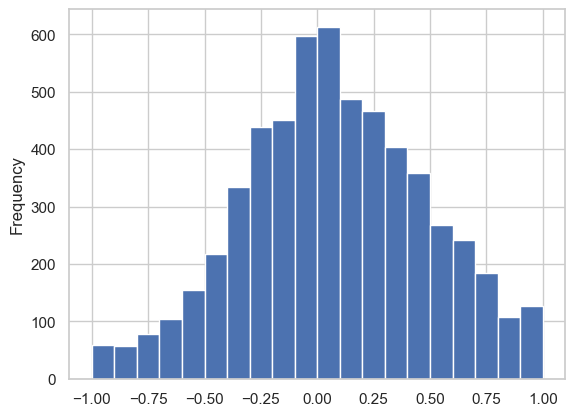

In [34]:
%%time
# res["cos_sim"].plot(kind="kde")
res["cos_sim"].plot(kind="hist", bins=20)

## 2.2. Mutual Information

In [35]:
# %%time
# # res["mutual_info"].plot(kind="kde")
# res["mutual_info"].plot(kind="hist", bins=20)

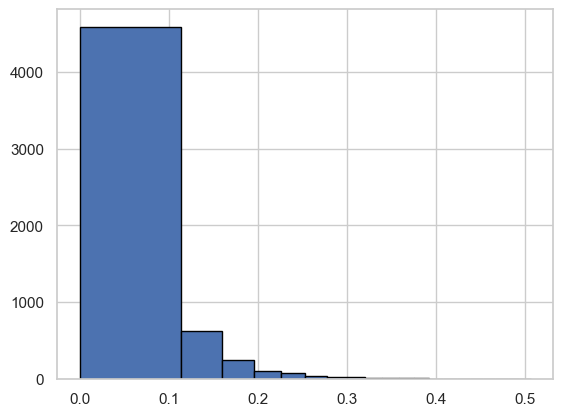

In [36]:

bins_4 = create_bins(res["mutual_info"].min(), res["mutual_info"].max(), n_bins=20, alpha=0.5, smoothing=False)
plt.hist(res["mutual_info"], bins=bins_4, edgecolor='black')
# plt.xscale('log')
plt.show()

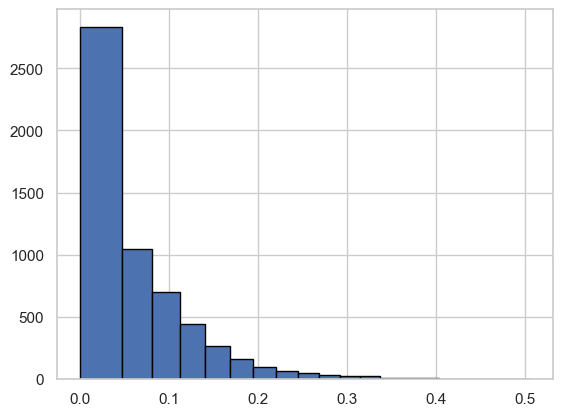

In [37]:

bins_4 = create_bins(res["mutual_info"].min(), res["mutual_info"].max(), n_bins=20, alpha=0.5, smoothing=True)
plt.hist(res["mutual_info"], bins=bins_4, edgecolor='black')
# plt.xscale('log')
plt.show()

In [38]:
print(1.5**(4./5.) )
print(.5**(1./3.) )

1.3831618672225916
0.7937005259840998


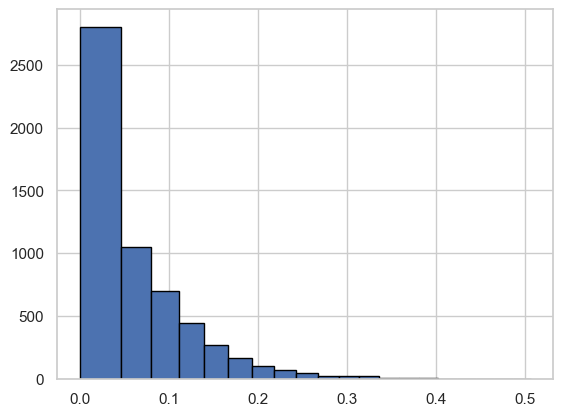

In [39]:

bins_4 = create_bins(res["mutual_info"].min(), res["mutual_info"].max(), n_bins=20, alpha=0.8, smoothing=False)
plt.hist(res["mutual_info"], bins=bins_4, edgecolor='black')
# plt.xscale('log')
plt.show()

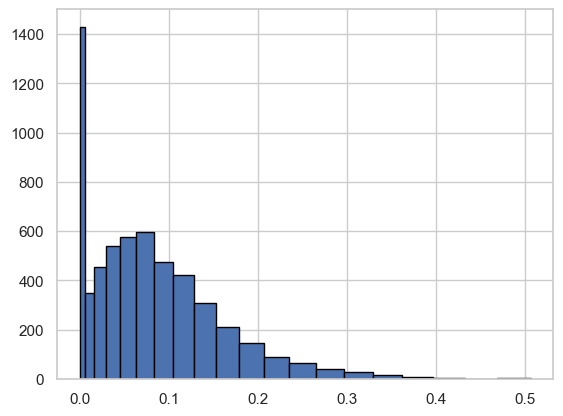

In [40]:
bins_4 = create_bins(res["mutual_info"].min(), res["mutual_info"].max(), n_bins=20, alpha=1.5, smoothing=False)
plt.hist(res["mutual_info"], bins=bins_4, edgecolor='black')
# plt.xscale('log')
plt.show()

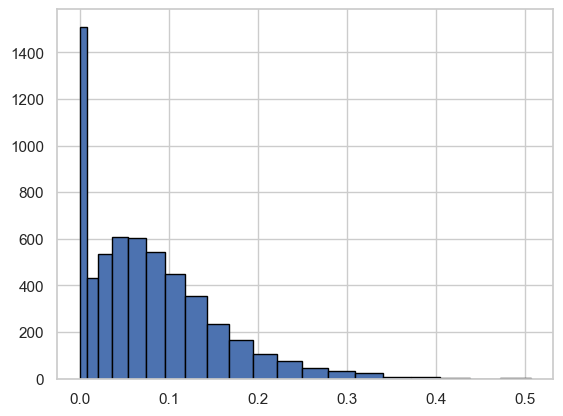

In [41]:
bins_4 = create_bins(res["mutual_info"].min(), res["mutual_info"].max(), n_bins=20, alpha=1.5, smoothing=True)
plt.hist(res["mutual_info"], bins=bins_4, edgecolor='black')
# plt.xscale('log')
plt.show()

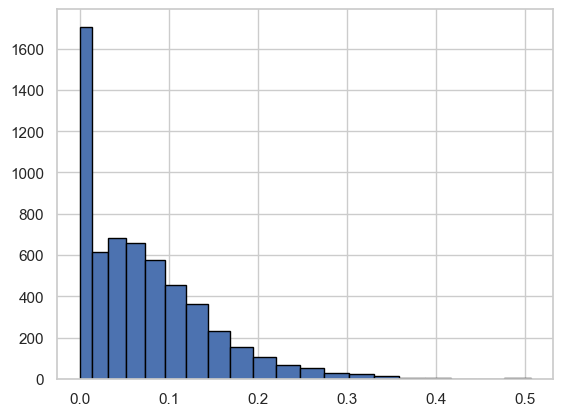

In [42]:
bins_4 = create_bins(res["mutual_info"].min(), res["mutual_info"].max(), n_bins=20, alpha=1.2, smoothing=False)
plt.hist(res["mutual_info"], bins=bins_4, edgecolor='black')
# plt.xscale('log')
plt.show()

<Axes: ylabel='Frequency'>

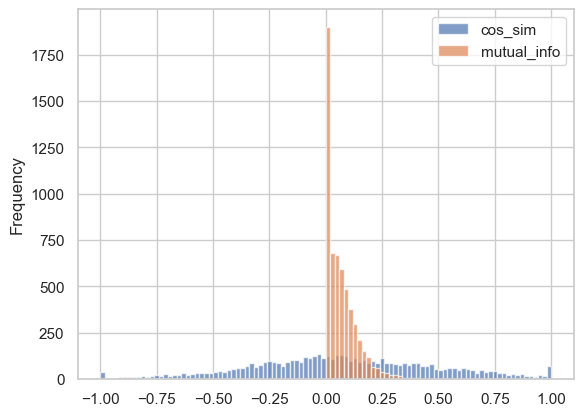

In [43]:
# res.plot(kind="kde", alpha=0.7)
res.plot(kind="hist", bins=100, alpha=0.7)


### Generate figs

In [44]:
X.shape

(171, 5748)

Directory already exists: outputs/extracted_results/imgs


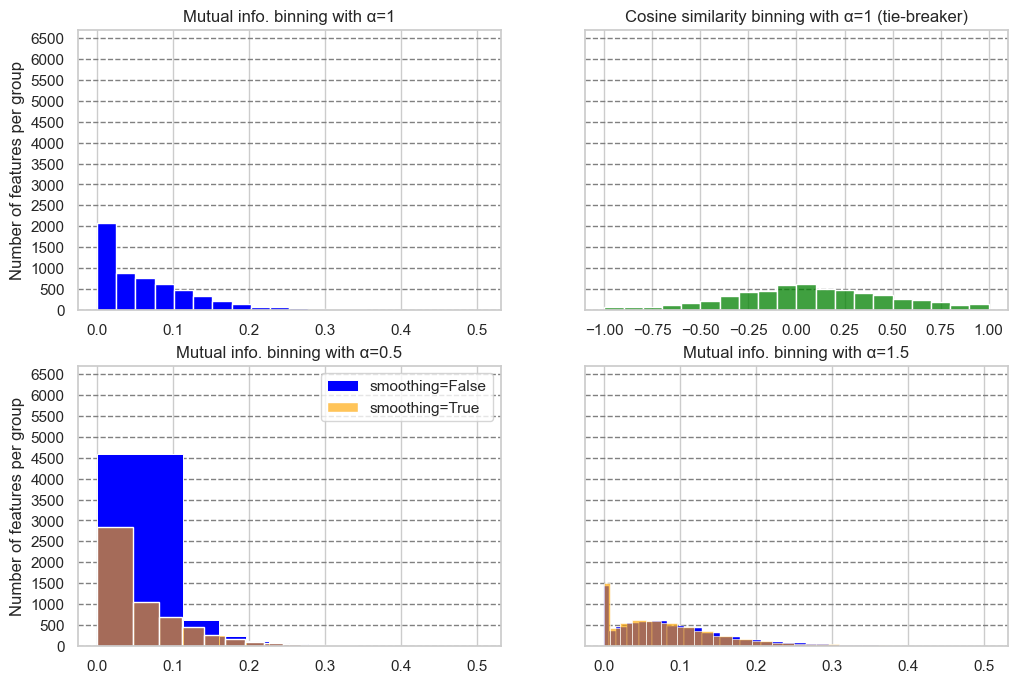

In [45]:
imgs_saving_dir = "./outputs/extracted_results/imgs"
check_or_create_directory(imgs_saving_dir)

fig, ax = plt.subplots(nrows=2, ncols =2, figsize=(12,8))
ax = ax.flatten()

n_bins = 20
ymin, ymax = 0, 6700

bins_4 = create_bins(res["mutual_info"].min(), res["mutual_info"].max(), n_bins=n_bins, alpha=1, smoothing=False)
sns.histplot(x=res["mutual_info"].values,  bins=bins_4, alpha=1, color="blue", ax=ax[0])

bins_4 = create_bins(res["cos_sim"].min(), res["cos_sim"].max(), n_bins=n_bins, alpha=1, smoothing=False)
sns.histplot(x=res["cos_sim"].values,  bins=bins_4, color="green", ax=ax[1])

bins_4 = create_bins(res["mutual_info"].min(), res["mutual_info"].max(), n_bins=n_bins, alpha=.5, smoothing=False)
sns.histplot(x=res["mutual_info"].values,  bins=bins_4, alpha=1, color="blue", ax=ax[2], label="smoothing=False")
    
bins_4 = create_bins(res["mutual_info"].min(), res["mutual_info"].max(), n_bins=n_bins, alpha=.5, smoothing=True)
sns.histplot(x=res["mutual_info"].values,  bins=bins_4, alpha=0.65, color="orange", ax=ax[2], label="smoothing=True")

bins_4 = create_bins(res["mutual_info"].min(), res["mutual_info"].max(), n_bins=n_bins, alpha=1.5, smoothing=False)
sns.histplot(x=res["mutual_info"].values,  bins=bins_4, alpha=1, color="blue", ax=ax[3], label="smoothing=False")
    
bins_4 = create_bins(res["mutual_info"].min(), res["mutual_info"].max(), n_bins=n_bins, alpha=1.5, smoothing=True)
sns.histplot(x=res["mutual_info"].values,  bins=bins_4, alpha=0.65, color="orange", ax=ax[3], label="smoothing=True")

idx_figtitle_mapping ={
    0 : "Mutual info. binning with α=1",
    1 : "Cosine similarity binning with α=1 (tie-breaker)",
    2 : "Mutual info. binning with α=0.5",
    3 : "Mutual info. binning with α=1.5",
}

ax[2].legend()
for i in range(4):
    
    ax[i].set_title(idx_figtitle_mapping[i])
    ax[i].set_ylim(ymin,ymax)
    ax[i].set_yticks(np.arange(ymin,ymax,500))
    ax[i].grid(color='gray', linestyle='dashed', axis='y', which='major')
    if i in [0,2]:
        ax[i].set_ylabel("Number of features per group")
        ax[i+1].set_yticklabels([])
        ax[i+1].set_ylabel("")
        # if i < len(ax)-6:
        #     ax[i].set_xticklabels([])
        # if i not in [0,5,10]:
        #     ax[i].set_yticklabels([])

fig.savefig(imgs_saving_dir+"/binning_resizing_and_smoothing.png", dpi=600, bbox_inches='tight')
fig.show()


In [46]:
# res

In [47]:
# cluster_features?

In [48]:
df_clusters, _, _ = cluster_features(
    res.drop(["cos_sim"], axis=1), 
    value_column = "mutual_info",
    n_clusters=20,
    alpha = 1.0,
)
# df_clusters

In [49]:
df_clusters["mutual_info_clusters"].value_counts()#.plot(kind="hist")

# sns.histplot(x="mutual_info_clusters", alpha=1, color="blue", label="smoothing=False", data=df_clusters, rotation=90)

mutual_info_clusters
ft_cluster_1     2079
ft_cluster_2      883
ft_cluster_3      771
ft_cluster_4      614
ft_cluster_5      471
ft_cluster_6      325
ft_cluster_7      201
ft_cluster_8      144
ft_cluster_9       79
ft_cluster_10      68
ft_cluster_11      35
ft_cluster_12      28
ft_cluster_13      21
ft_cluster_14      13
ft_cluster_15       6
ft_cluster_16       5
ft_cluster_19       2
ft_cluster_17       1
ft_cluster_18       1
ft_cluster_20       1
Name: count, dtype: int64

## 2.3. ANOVA F-value

In [50]:
# Import f_classif from Scikit-learn
from sklearn.feature_selection import f_classif, f_regression, chi2, f_oneway, GenericUnivariateSelect
# import sklearn.feature_selection as FS 

In [51]:
%%time
res_fscore = pd.DataFrame(
    {"features":X.columns, 
     "fvalue":f_classif(X, y)[0]}
).fillna(0.0)

res_fscore["mutual_info"] = res["mutual_info"]

CPU times: user 59.8 ms, sys: 5.35 ms, total: 65.1 ms
Wall time: 23.7 ms


In [52]:
res_fscore.describe()

,fvalue,mutual_info
count,5748.000000,5748.000000
mean,6.230730,0.064959
std,7.507151,0.068119
min,0.005233,0.000000
25%,1.644943,0.006066
50%,3.648491,0.047895
75%,7.974902,0.098926
max,88.397655,0.506279


In [53]:
res_fscore = handle_inf_values(res_fscore, keep_inf_values_seperate=False, pct_change=0.0)

In [54]:
res_fscore.describe()

,fvalue,mutual_info
count,5748.000000,5748.000000
mean,6.230730,0.064959
std,7.507151,0.068119
min,0.005233,0.000000
25%,1.644943,0.006066
50%,3.648491,0.047895
75%,7.974902,0.098926
max,88.397655,0.506279


CPU times: user 13.2 ms, sys: 1.91 ms, total: 15.1 ms
Wall time: 14 ms


<Axes: ylabel='Frequency'>

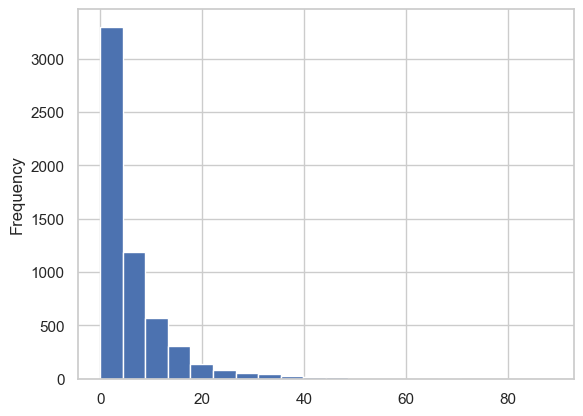

In [55]:
%%time
res_fscore["fvalue"].plot(kind="hist", bins=20)

In [56]:
%%time
# res_fscore["fvalue"].plot(kind="kde")
# res_fscore.plot(kind="hist", bins=20, alpha=0.7)

CPU times: user 1 µs, sys: 0 ns, total: 1 µs
Wall time: 9.06 µs


In [57]:
# df_clusters["fvalue"].value_counts()

In [58]:
df_clusters, _, _ = cluster_features(
    res_fscore.drop(["mutual_info"], axis=1), 
    value_column = "fvalue",
    n_clusters=100,
    alpha = 1.0,
)
df_clusters

,features,fvalue,fvalue_clusters
0,col_0,1.341650,ft_cluster_2
1,col_1,0.976751,ft_cluster_2
2,col_2,3.183118,ft_cluster_4
3,col_3,24.580294,ft_cluster_28
4,col_4,1.363541,ft_cluster_2
...,...,...,...
5743,col_5743,11.033002,ft_cluster_13
5744,col_5744,17.173982,ft_cluster_20
5745,col_5745,7.030067,ft_cluster_8
5746,col_5746,1.099719,ft_cluster_2


In [59]:
print((df_clusters["fvalue_clusters"].value_counts() > 0).sum())

64


In [60]:
for i, n_clusters in enumerate(range (2,101)):
    df_clusters, _, _ = cluster_features(
        res_fscore.drop(["mutual_info"], axis=1), 
        value_column = "fvalue",
        n_clusters=n_clusters,
        alpha = 1.0,
    )
    print(i, "=> ",(df_clusters["fvalue_clusters"].value_counts() > 0).sum())

0 =>  2
1 =>  3
2 =>  4
3 =>  5
4 =>  6
5 =>  7
6 =>  8
7 =>  9
8 =>  9
9 =>  10
10 =>  11
11 =>  12
12 =>  12
13 =>  13
14 =>  14
15 =>  15
16 =>  16
17 =>  15
18 =>  17
19 =>  18
20 =>  18
21 =>  20
22 =>  19
23 =>  21
24 =>  21
25 =>  22
26 =>  23
27 =>  23
28 =>  24
29 =>  24
30 =>  26
31 =>  25
32 =>  26
33 =>  27
34 =>  28
35 =>  29
36 =>  28
37 =>  29
38 =>  30
39 =>  31
40 =>  31
41 =>  31
42 =>  33
43 =>  33
44 =>  34
45 =>  33
46 =>  34
47 =>  36
48 =>  36
49 =>  37
50 =>  36
51 =>  38
52 =>  38
53 =>  39
54 =>  39
55 =>  39
56 =>  40
57 =>  42
58 =>  42
59 =>  41
60 =>  44
61 =>  43
62 =>  44
63 =>  44
64 =>  45
65 =>  45
66 =>  47
67 =>  47
68 =>  46
69 =>  48
70 =>  48
71 =>  49
72 =>  49
73 =>  50
74 =>  50
75 =>  51
76 =>  52
77 =>  51
78 =>  53
79 =>  53
80 =>  54
81 =>  54
82 =>  56
83 =>  55
84 =>  56
85 =>  57
86 =>  58
87 =>  58
88 =>  59
89 =>  59
90 =>  59
91 =>  61
92 =>  60
93 =>  60
94 =>  62
95 =>  63
96 =>  63
97 =>  64
98 =>  64


## 2.4. Variance 

In [61]:
# Import VarianceThreshold from Scikit-learn
from sklearn.feature_selection import VarianceThreshold

In [62]:
# SelectKBest
# VarianceThreshold?

In [63]:
# Create VarianceThreshold object to perform variance thresholding
selector_var = VarianceThreshold()

# Perform variance thresholding
selector_var.fit(X)

,threshold,0.0


In [64]:
from scipy.stats import entropy, variation

calc_entropy = lambda x: entropy(x.value_counts(), base=2)
calc_variation = lambda x: variation(x, nan_policy='omit') 

calc_variance = lambda x: np.nanvar(x, axis=0)

In [65]:
# variation = X_train.apply(calc_variation).values
variance1 = X.apply(calc_variance).values
variance2 = calc_variance(X)
# plt.plot(variance)
(variance1 == variance2).all() , (variance1 == selector_var.variances_).all(),  variance1.shape

(True, True, (5748,))

In [66]:
# res.columns

In [67]:
%%time
res_var = res[
    [
        "features", 
        "mutual_info",
        "cos_sim",
        # "mutual_info",
    ]
]
# res_var["fvalue"] = res_fscore["fvalue"].values
res_var["variance"] = X.apply(calc_variance).values
res_var.fillna(0., inplace=True)


CPU times: user 193 ms, sys: 8.97 ms, total: 202 ms
Wall time: 197 ms


In [68]:
res_var.describe()
# res_var

,mutual_info,cos_sim,variance
count,5748.000000,5748.000000,5.748000e+03
mean,0.064959,0.076951,1.000000e+00
std,0.068119,0.410430,1.548567e-16
min,0.000000,-1.000000,1.000000e+00
25%,0.006066,-0.201894,1.000000e+00
50%,0.047895,0.062630,1.000000e+00
75%,0.098926,0.361894,1.000000e+00
max,0.506279,1.000000,1.000000e+00


In [69]:
# pd.DataFrame.plot.hist(bins=100)

CPU times: user 27.5 ms, sys: 2.65 ms, total: 30.1 ms
Wall time: 22.4 ms


<Axes: ylabel='Frequency'>

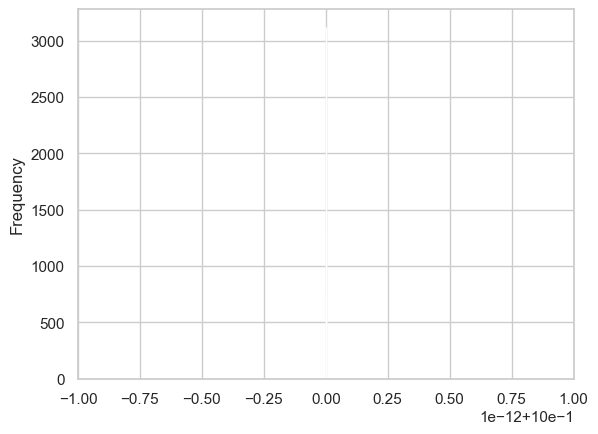

In [70]:
%%time
# res_var["variance"].plot(kind="kde")
res_var["variance"].plot(kind="hist", bins=100)

<Axes: ylabel='Frequency'>

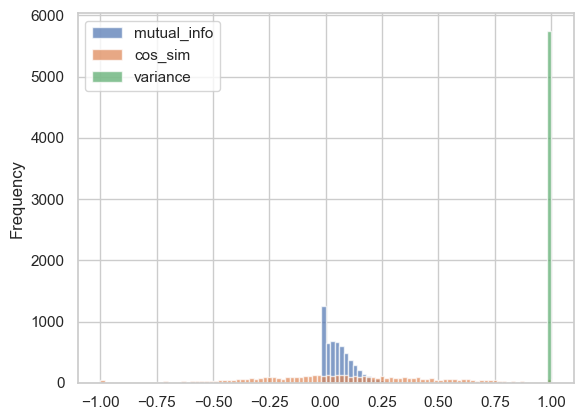

In [71]:
res_var.plot(kind="hist", bins=100, alpha=0.7)

## 2.5. Gini importance

In [72]:
# For Gini importance-based FFS
default_RF_params , _ = get_model_default_params_and_param_grid(model=RandomForestClassifier, random_state=RANDOM_STATE)

In [73]:
rf_clf = RandomForestClassifier(**default_RF_params)
rf_clf.fit(X,y)
res_gini = pd.DataFrame({FEATURES_COL_NAME:rf_clf.feature_names_in_ , "gini_importance":rf_clf.feature_importances_})
res_gini["mutual_info"] = mutual_info_classif(X, y, random_state=RANDOM_STATE, n_jobs=-1,)
res_gini.fillna(0., inplace=True)

In [74]:
res_gini.describe()

,gini_importance,mutual_info
count,5748.000000,5748.000000
mean,0.000174,0.064959
std,0.000460,0.068119
min,0.000000,0.000000
25%,0.000000,0.006066
50%,0.000000,0.047895
75%,0.000142,0.098926
max,0.007467,0.506279


<Axes: ylabel='Frequency'>

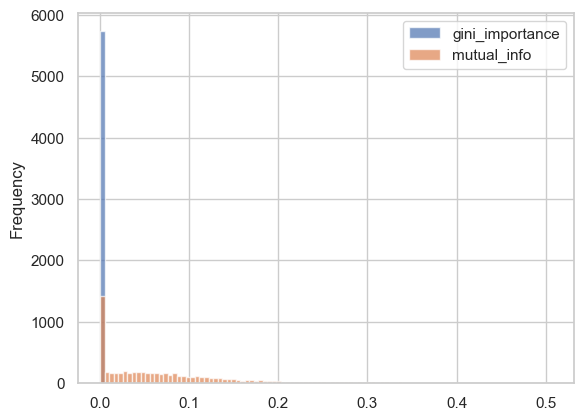

In [75]:
res_gini.plot(kind="hist", bins=100, alpha=0.7)